In [1]:
import onnx
import onnxruntime as ort

2025-12-10 10:40:46.844075954 [W:onnxruntime:Default, device_discovery.cc:164 DiscoverDevicesForPlatform] GPU device discovery failed: device_discovery.cc:89 ReadFileContents Failed to open file: "/sys/class/drm/card0/device/vendor"


In [2]:
import torchvision.transforms as T

In [3]:
import numpy as np

In [4]:
import matplotlib.pyplot as plt

In [5]:
from PIL import Image

In [6]:
from pathlib import Path

In [7]:
onnx_path = "../onnx/DA3-BASE.onnx"

In [8]:
sess = ort.InferenceSession(onnx_path, providers=["CPUExecutionProvider"])

In [9]:
sess

In [10]:
# Get input names
input_names = [i.name for i in sess.get_inputs()]
input_names

['image', 'extrinsics', 'intrinsics']

In [11]:
target_h = 280
target_w = 504

In [12]:
def preprocess_image(image_path: Path, target_h: int, target_w: int):
    """Load and preprocess an image to (1, 3, H, W) normalized float32."""
    img = Image.open(image_path).convert("RGB").resize((target_w, target_h), Image.BILINEAR)
    transform = T.Compose(
        [T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]
    )
    tensor = transform(img).unsqueeze(0)  # (1,3,H,W)
    return tensor.numpy().astype(np.float32).squeeze(), img

In [13]:
image_path = "../../../../data/depth_measurements/full_res_captured_frames/full_image_32.png"

In [14]:
image_np, img = preprocess_image(image_path, target_h, target_w)

In [15]:
extrinsics_np = np.zeros((4, 4), dtype=np.float32)
intrinsics_np = np.zeros((3, 3), dtype=np.float32)

In [16]:
inputs = {
    "image": image_np,
    "extrinsics": extrinsics_np,
    "intrinsics": intrinsics_np,
}

outputs = sess.run([o.name for o in sess.get_outputs()], inputs)
out_dict = dict(zip([o.name for o in sess.get_outputs()], outputs))
depth = out_dict["depth"]

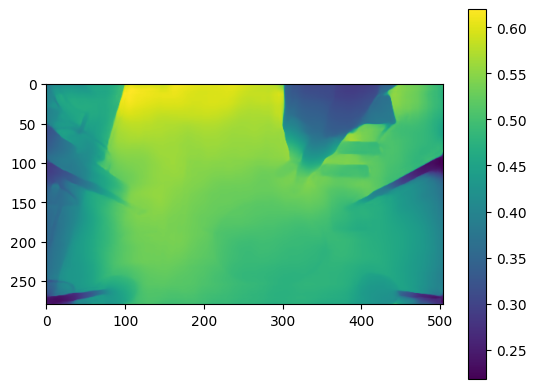

In [17]:
plt.imshow(depth.squeeze())
plt.colorbar()

In [18]:
cam_intrinsics = np.array([
[1498.00,    0.0, 1040.0],
[   0.0, 1494.0,  772.0],
[   0.0,    0.0,    1.0]], dtype=np.float32)

In [19]:
w2c_extrinsics = np.array([[ 9.99962114e-01, -2.94180227e-03,  8.19247358e-03, -1.70403450e+01],
[ 0.00000000e+00, -9.41161265e-01, -3.37957799e-01,  7.02952222e+02],
[ 8.70464381e-03,  3.37944995e-01, -9.41125608e-01,  1.95754126e+03],
[ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.00000000e+00]], dtype=np.float32)
cam_extrinsics = w2c_extrinsics

In [20]:
cam_extrinsics.shape

(4, 4)

In [21]:
cam_intrinsics.shape

(3, 3)

In [22]:
inputs = {
    "image": image_np,
    "extrinsics": cam_extrinsics,
    "intrinsics": cam_intrinsics,
}

outputs = sess.run([o.name for o in sess.get_outputs()], inputs)
out_dict = dict(zip([o.name for o in sess.get_outputs()], outputs))
depth = out_dict["depth"]

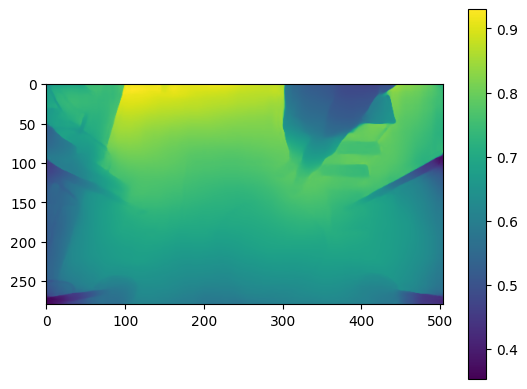

In [23]:
plt.imshow(depth.squeeze())
plt.colorbar()

## TensorRT-like processing
- Crop original image: `1560x2104` → `1554x2100` divisible by 14
- Resize to inference size: `280×378`
- Run ONNX/TensorRT inference
- Upscale depth map to `1554×2100` → then optionally pad to `1560×2104`
- Aspect ratio preserved → depth maps correctly to 3D space
- Minimal preprocessing → very fast on Jetson Nano
- Memory-efficient → small ONNX input

In [24]:
crop_width = 2100
crop_height = 1554

In [25]:
original_width = 2104
original_height = 1560

In [26]:
x_start = (original_width - crop_width) // 2
y_start = (original_height - crop_height) // 2
x_end = x_start + crop_width
y_end = y_start + crop_height

In [27]:
cropped_img = np.array(Image.open(image_path).convert("RGB"))[y_start:y_end, x_start:x_end]
cropped_img.shape

(1554, 2100, 3)

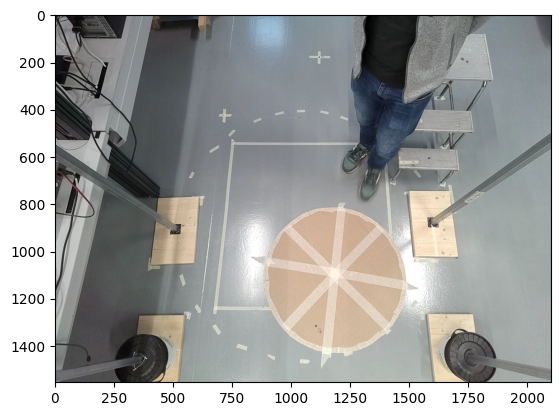

In [28]:
plt.imshow(cropped_img)

In [29]:
def preprocess_image(img: np.array):
    """Load and preprocess an image to (1, 3, H, W) normalized float32."""
    transform = T.Compose(
        [T.ToTensor(), T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])]
    )
    tensor = transform(img).unsqueeze(0)  # (1,3,H,W)
    return tensor.numpy().astype(np.float32).squeeze(), img

In [30]:
target_h = 280
target_w = 378

In [31]:
cropped_img.shape

(1554, 2100, 3)

In [32]:
resized_img, _ = preprocess_image(cropped_img)
resized_img.shape

(3, 1554, 2100)

In [33]:
def rescale_intrinsics(
    intrinsics: np.ndarray,
    orig_h: int,
    orig_w: int,
    target_h: int,
    target_w: int,
    divisible_by: int = 14
) -> np.ndarray:
    """
    Scale camera intrinsics to match a resized/padded input for a neural network.

    Args:
        intrinsics: Original 3x3 camera intrinsics matrix.
        orig_h: Original image height.
        orig_w: Original image width.
        target_h: Target network input height.
        target_w: Target network input width.
        divisible_by: Optional: crop to nearest multiple of this before resizing.

    Returns:
        scaled_intrinsics: 3x3 intrinsics matrix adjusted for resize/padding.
    """
    # --- Step 1: crop to be divisible by 'divisible_by' ---
    new_h = (orig_h // divisible_by) * divisible_by
    new_w = (orig_w // divisible_by) * divisible_by
    crop_top = (orig_h - new_h) // 2
    crop_left = (orig_w - new_w) // 2

    # --- Step 2: compute scale factor to fit target size while preserving aspect ratio ---
    scale_h = target_h / new_h
    scale_w = target_w / new_w
    scale = min(scale_h, scale_w)

    # --- Step 3: compute padding to reach exact target size ---
    resized_h = int(new_h * scale)
    resized_w = int(new_w * scale)
    pad_top = (target_h - resized_h) // 2
    pad_left = (target_w - resized_w) // 2

    # --- Step 4: scale intrinsics ---
    scaled_intrinsics = intrinsics.copy()
    # Adjust principal point
    scaled_intrinsics[0,2] = (scaled_intrinsics[0,2] - crop_left) * scale + pad_left
    scaled_intrinsics[1,2] = (scaled_intrinsics[1,2] - crop_top) * scale + pad_top
    # Adjust focal lengths
    scaled_intrinsics[0,0] *= scale
    scaled_intrinsics[1,1] *= scale

    return scaled_intrinsics.astype(np.float32)

In [34]:
rescaled_cam_intrinsics = rescale_intrinsics(
    intrinsics=cam_intrinsics,
    orig_h=crop_height,
    orig_w=crop_width,
    target_h=target_h,
    target_w=target_w
)
rescaled_cam_intrinsics

array([[269.64,   0.  , 187.2 ],
       [  0.  , 268.92, 138.96],
       [  0.  ,   0.  ,   1.  ]], dtype=float32)

In [35]:
resized_img.shape

(3, 1554, 2100)

In [36]:
inputs = {
    "image": resized_img,
    "extrinsics": cam_extrinsics,
    "intrinsics": rescaled_cam_intrinsics,
}

outputs = sess.run([o.name for o in sess.get_outputs()], inputs)
out_dict = dict(zip([o.name for o in sess.get_outputs()], outputs))
depth = out_dict["depth"]

InvalidArgument: [ONNXRuntimeError] : 2 : INVALID_ARGUMENT : Got invalid dimensions for input: image for the following indices
 index: 1 Got: 1554 Expected: 280
 index: 2 Got: 2100 Expected: 504
 Please fix either the inputs/outputs or the model.